In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import copy

from torchvision import models, transforms
from torchvision.models import EfficientNet_B0_Weights

from PIL import Image
import pandas as pd
from pathlib import Path
from tqdm import tqdm

from google.colab import drive

drive.mount("/content/drive")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


Mounted at /content/drive
cuda
NVIDIA L4


In [3]:
SPLIT_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/splits")

train_df_double = pd.read_csv(SPLIT_DIR / "train_diff_double.csv")
train_df_balanced = pd.read_csv(SPLIT_DIR / "train_diff_balanced.csv")
val_df = pd.read_csv(SPLIT_DIR / "val_split.csv")
test_df = pd.read_csv(SPLIT_DIR / "test_split.csv")

print(train_df_double.head())
print(train_df_double["label"].value_counts())

print(train_df_balanced.head())
print(train_df_balanced["label"].value_counts())

        isic_id   lesion_id                 diagnosis_3  binary_label  label  \
0  ISIC_0024307  IL_6125741                       Nevus  Non-Melanoma      0   
1  ISIC_0024308  IL_3692653                       Nevus  Non-Melanoma      0   
2  ISIC_0024309  IL_0959663                       Nevus  Non-Melanoma      0   
3  ISIC_0024310  IL_8194852               Melanoma, NOS      Melanoma      1   
4  ISIC_0024312  IL_3471258  Pigmented benign keratosis  Non-Melanoma      0   

                                          image_path  
0  /content/drive/MyDrive/bachelor_thesis_data/HA...  
1  /content/drive/MyDrive/bachelor_thesis_data/HA...  
2  /content/drive/MyDrive/bachelor_thesis_data/HA...  
3  /content/drive/MyDrive/bachelor_thesis_data/HA...  
4  /content/drive/MyDrive/bachelor_thesis_data/HA...  
label
0    7261
1    1886
Name: count, dtype: int64
        isic_id   lesion_id                 diagnosis_3  binary_label  label  \
0  ISIC_0024307  IL_6125741                       Nevus  

In [4]:
weights = EfficientNet_B0_Weights.DEFAULT

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
import os
import numpy as np
import random

SEED = 42

def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(SEED)

print(f"Random seed: {SEED}")

Random seed: 42


In [6]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


In [6]:
!mkdir -p /content/HAM10000_images
!rsync -ah --info=progress2 /content/drive/MyDrive/bachelor_thesis_data/HAM10000_ISIC/images/ /content/HAM10000_images/

        326.28M 100%   33.09kB/s    2:40:30 (xfr#11721, to-chk=0/11722)   


In [12]:
from pathlib import Path

old_real_path = "/content/drive/MyDrive/bachelor_thesis_data/HAM10000_ISIC/images"
new_real_path = "/content/HAM10000_images"

val_df["image_path"] = val_df["image_path"].str.replace(
    old_real_path,
    new_real_path,
    regex=False
)

test_df["image_path"] = test_df["image_path"].str.replace(
    old_real_path,
    new_real_path,
    regex=False
)

In [13]:
import shutil
from pathlib import Path

LOCAL_DIFF_DIR = Path("/content/diff_synthetic_images")

LOCAL_DIFF_DIR.mkdir(parents=True, exist_ok=True)

def copy_synthetic_images(
    train_df: pd.DataFrame,
    local_directory: Path
):
    synthetic_df = train_df[
        train_df["isic_id"].astype(str).str.startswith("synthetic_")
    ]

    print(f"Synthetic rows found: {len(synthetic_df)}")

    for source_path in tqdm(
        synthetic_df["image_path"],
        desc=f"Copying to {local_directory.name}"
    ):
        source_path = Path(source_path)
        destination_path = local_directory / source_path.name

        if not destination_path.exists():
            shutil.copy2(source_path, destination_path)

    copied_count = len(list(local_directory.glob("*.png")))
    print(f"Images available locally: {copied_count}")

copy_synthetic_images(
    train_df_balanced,
    LOCAL_DIFF_DIR
)


Synthetic rows found: 6318


Copying to diff_synthetic_images: 100%|██████████| 6318/6318 [00:00<00:00, 71307.98it/s]

Images available locally: 6318


In [14]:
def convert_to_local_paths(
    dataframe: pd.DataFrame,
    local_synthetic_directory: Path
):
    dataframe = dataframe.copy()

    synthetic_mask = (
        dataframe["isic_id"]
        .astype(str)
        .str.startswith("synthetic_")
    )

    # Synthetic images
    dataframe.loc[synthetic_mask, "image_path"] = (
        dataframe.loc[synthetic_mask, "image_path"]
        .apply(
            lambda path:
            str(local_synthetic_directory / Path(path).name)
        )
    )

    # Real HAM10000 images
    dataframe.loc[~synthetic_mask, "image_path"] = (
        dataframe.loc[~synthetic_mask, "image_path"]
        .apply(
            lambda path:
            str(Path("/content/HAM10000_images") / Path(path).name)
        )
    )

    return dataframe

train_df_double = convert_to_local_paths(
    train_df_double,
    LOCAL_DIFF_DIR
)

train_df_balanced = convert_to_local_paths(
    train_df_balanced,
    LOCAL_DIFF_DIR
)

In [15]:
def check_paths(name, dataframe):
    exists = dataframe["image_path"].apply(
        lambda path: Path(path).exists()
    )

    print(f"{name}:")
    print(f"  Total rows: {len(dataframe)}")
    print(f"  Existing files: {exists.sum()}")
    print(f"  Missing files: {(~exists).sum()}")

    if (~exists).any():
        print("\nExample missing paths:")
        print(
            dataframe.loc[~exists, "image_path"].head()
        )

check_paths("double training set", train_df_double)
check_paths("balanced training set", train_df_balanced)
check_paths("Validation set", val_df)
check_paths("Test set", test_df)

double training set:
  Total rows: 9147
  Existing files: 9147
  Missing files: 0
balanced training set:
  Total rows: 14522
  Existing files: 14522
  Missing files: 0
Validation set:
  Total rows: 1742
  Existing files: 1742
  Missing files: 0
Test set:
  Total rows: 1774
  Existing files: 1774
  Missing files: 0


In [7]:
class MelanomaDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_path = row["image_path"]
        label = row["label"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.float32)

        return image, label

In [8]:
BATCH_SIZE = 32

generator_double = torch.Generator()
generator_double.manual_seed(SEED)

generator_balanced = torch.Generator()
generator_balanced.manual_seed(SEED)

train_double_dataset = MelanomaDataset(
    train_df_double,
    transform=train_transform
)

train_balanced_dataset = MelanomaDataset(
    train_df_balanced,
    transform=train_transform
)

val_dataset = MelanomaDataset(
    val_df,
    transform=val_test_transform
)

test_dataset = MelanomaDataset(
    test_df,
    transform=val_test_transform
)

train_loader_double = DataLoader(
    train_double_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    worker_init_fn=seed_worker,
    generator=generator_double
)

train_loader_balanced = DataLoader(
    train_balanced_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    worker_init_fn=seed_worker,
    generator=generator_balanced
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    worker_init_fn=seed_worker
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    worker_init_fn=seed_worker
)

In [9]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(dataloader):
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader):
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.sigmoid(outputs)

            running_loss += loss.item() * images.size(0)

            all_labels.extend(labels.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())

    epoch_loss = running_loss / len(dataloader.dataset)

    return epoch_loss, all_labels, all_probs

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

#recreate model from scratch

set_seed(SEED)
generator_double.manual_seed(SEED)

weights = EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(weights=weights)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 1)

model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def calculate_metrics(labels, probs, threshold=0.5):
    preds = [1 if p >= threshold else 0 for p in probs]

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs)
    }

EPOCHS = 20

history = []
best_val_f1 = -1.0
best_model_state = None
best_epoch = 0

#train loop

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss = train_one_epoch(
        model=model,
        dataloader=train_loader_double,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_labels, val_probs = evaluate(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device
    )

    val_metrics = calculate_metrics(
        labels=val_labels,
        probs=val_probs,
        threshold=0.5
    )

    epoch_results = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "accuracy": val_metrics["accuracy"],
        "precision": val_metrics["precision"],
        "recall": val_metrics["recall"],
        "f1": val_metrics["f1"],
        "roc_auc": val_metrics["roc_auc"]
    }

    history.append(epoch_results)

    print(f"Train loss: {train_loss:.4f}")
    print(f"Val loss: {val_loss:.4f}")
    print(f"Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Precision: {val_metrics['precision']:.4f}")
    print(f"Recall: {val_metrics['recall']:.4f}")
    print(f"F1-score: {val_metrics['f1']:.4f}")
    print(f"ROC-AUC: {val_metrics['roc_auc']:.4f}")

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        print("New best model saved.")

history_df = pd.DataFrame(history)

model.load_state_dict(best_model_state)

print("\nTraining finished.")
print(f"Best epoch: {best_epoch}")
print(f"Best validation F1-score: {best_val_f1:.4f}")

CHECKPOINT_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/checkpoints")
RESULTS_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/results/tables")

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

torch.save(
    best_model_state,
    CHECKPOINT_DIR / "diffusion_augmentation_double.pth"
)

history_df.to_csv(
    RESULTS_DIR / "diffusion_augmentation_double_training_history.csv",
    index=False
)

print("\nSaved.")

best_val_loss, best_val_labels, best_val_probs = evaluate(
    model=model,
    dataloader=val_loader,
    criterion=criterion,
    device=device
)

best_val_metrics = calculate_metrics(
    labels=best_val_labels,
    probs=best_val_probs,
    threshold=0.5
)

best_val_preds = [1 if p >= 0.5 else 0 for p in best_val_probs]
best_cm = confusion_matrix(best_val_labels, best_val_preds)

print("\nBest model validation results:")
print(f"Val loss: {best_val_loss:.4f}")
print(f"Accuracy: {best_val_metrics['accuracy']:.4f}")
print(f"Precision: {best_val_metrics['precision']:.4f}")
print(f"Recall: {best_val_metrics['recall']:.4f}")
print(f"F1-score: {best_val_metrics['f1']:.4f}")
print(f"ROC-AUC: {best_val_metrics['roc_auc']:.4f}")
print("Confusion matrix:")
print(best_cm)

history_df

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 238MB/s]



Epoch 1/20


100%|██████████| 55/55 [00:04<00:00, 12.40it/s]


Train loss: 0.2739
Val loss: 0.2357
Accuracy: 0.9013
Precision: 0.5574
Recall: 0.5285
F1-score: 0.5426
ROC-AUC: 0.8949
New best model saved.

Epoch 2/20


...

100%|██████████| 55/55 [00:04<00:00, 12.46it/s]


Train loss: 0.0098
Val loss: 0.5308
Accuracy: 0.9059
Precision: 0.6142
Recall: 0.4041
F1-score: 0.4875
ROC-AUC: 0.8794

Training finished.
Best epoch: 16
Best validation F1-score: 0.5764

Saved.


100%|██████████| 55/55 [00:04<00:00, 12.01it/s]


Best model validation results:
Val loss: 0.3934
Accuracy: 0.9013
Precision: 0.5493
Recall: 0.6062
F1-score: 0.5764
ROC-AUC: 0.9071
Confusion matrix:
[[1453   96]
 [  76  117]]


,epoch,train_loss,val_loss,accuracy,precision,recall,f1,roc_auc
0,1,0.273868,0.235747,0.901263,0.557377,0.528497,0.542553,0.894928
1,2,0.163970,0.229248,0.906429,0.605634,0.445596,0.513433,0.896574
2,3,0.105354,0.298118,0.895522,0.547826,0.326425,0.409091,0.858040
3,4,0.065720,0.287693,0.896670,0.528634,0.621762,0.571429,0.900397
4,5,0.043487,0.320660,0.902411,0.562842,0.533679,0.547872,0.877230
5,6,0.039940,0.342811,0.906429,0.594937,0.487047,0.535613,0.880879
6,7,0.029204,0.372563,0.904707,0.580838,0.502591,0.538889,0.881481
7,8,0.023386,0.397439,0.910448,0.650407,0.414508,0.506329,0.865579
8,9,0.021352,0.394513,0.909874,0.609756,0.518135,0.560224,0.867560
9,10,0.020129,0.393630,0.899541,0.554217,0.476684,0.512535,0.880056


In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

set_seed(SEED)
generator_balanced.manual_seed(SEED)

weights = EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(weights=weights)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 1)

model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def calculate_metrics(labels, probs, threshold=0.5):
    preds = [1 if p >= threshold else 0 for p in probs]

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs)
    }

EPOCHS = 20

history = []
best_val_f1 = -1.0
best_model_state = None
best_epoch = 0

#train loop

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss = train_one_epoch(
        model=model,
        dataloader=train_loader_balanced,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_labels, val_probs = evaluate(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device
    )

    val_metrics = calculate_metrics(
        labels=val_labels,
        probs=val_probs,
        threshold=0.5
    )

    epoch_results = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "accuracy": val_metrics["accuracy"],
        "precision": val_metrics["precision"],
        "recall": val_metrics["recall"],
        "f1": val_metrics["f1"],
        "roc_auc": val_metrics["roc_auc"]
    }

    history.append(epoch_results)

    print(f"Train loss: {train_loss:.4f}")
    print(f"Val loss: {val_loss:.4f}")
    print(f"Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Precision: {val_metrics['precision']:.4f}")
    print(f"Recall: {val_metrics['recall']:.4f}")
    print(f"F1-score: {val_metrics['f1']:.4f}")
    print(f"ROC-AUC: {val_metrics['roc_auc']:.4f}")

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())
        print("New best model saved.")

history_df = pd.DataFrame(history)

model.load_state_dict(best_model_state)

print("\nTraining finished.")
print(f"Best epoch: {best_epoch}")
print(f"Best validation F1-score: {best_val_f1:.4f}")

CHECKPOINT_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/checkpoints")
RESULTS_DIR = Path("/content/drive/MyDrive/bachelor_thesis_data/results/tables")

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

torch.save(
    best_model_state,
    CHECKPOINT_DIR / "diffusion_augmentation_balanced.pth"
)

history_df.to_csv(
    RESULTS_DIR / "diffusion_augmentation_balanced_training_history.csv",
    index=False
)

print("\nSaved.")

best_val_loss, best_val_labels, best_val_probs = evaluate(
    model=model,
    dataloader=val_loader,
    criterion=criterion,
    device=device
)

best_val_metrics = calculate_metrics(
    labels=best_val_labels,
    probs=best_val_probs,
    threshold=0.5
)

best_val_preds = [1 if p >= 0.5 else 0 for p in best_val_probs]
best_cm = confusion_matrix(best_val_labels, best_val_preds)

print("\nBest model validation results:")
print(f"Val loss: {best_val_loss:.4f}")
print(f"Accuracy: {best_val_metrics['accuracy']:.4f}")
print(f"Precision: {best_val_metrics['precision']:.4f}")
print(f"Recall: {best_val_metrics['recall']:.4f}")
print(f"F1-score: {best_val_metrics['f1']:.4f}")
print(f"ROC-AUC: {best_val_metrics['roc_auc']:.4f}")
print("Confusion matrix:")
print(best_cm)

history_df


Epoch 1/20


100%|██████████| 55/55 [00:04<00:00, 12.81it/s]


Train loss: 0.1740
Val loss: 0.2386
Accuracy: 0.8949
Precision: 0.5403
Recall: 0.3472
F1-score: 0.4227
ROC-AUC: 0.8851
New best model saved.

Epoch 2/20


100%|██████████| 55/55 [00:04<00:00, 12.92it/s]


Train loss: 0.1098
Val loss: 0.2152
Accuracy: 0.9087
Precision: 0.6545
Recall: 0.3731
F1-score: 0.4752
ROC-AUC: 0.9098
New best model saved.

Epoch 3/20


...

100%|██████████| 55/55 [00:04<00:00, 12.47it/s]


Train loss: 0.0048
Val loss: 0.4128
Accuracy: 0.9082
Precision: 0.6093
Recall: 0.4767
F1-score: 0.5349
ROC-AUC: 0.8989

Training finished.
Best epoch: 11
Best validation F1-score: 0.5902

Saved.


100%|██████████| 55/55 [00:04<00:00, 12.34it/s]


Best model validation results:
Val loss: 0.4443
Accuracy: 0.9036
Precision: 0.5576
Recall: 0.6269
F1-score: 0.5902
ROC-AUC: 0.8985
Confusion matrix:
[[1453   96]
 [  72  121]]


,epoch,train_loss,val_loss,accuracy,precision,recall,f1,roc_auc
0,1,0.173954,0.238584,0.894948,0.540323,0.347150,0.422713,0.885077
1,2,0.109816,0.215191,0.908726,0.654545,0.373057,0.475248,0.909783
2,3,0.073366,0.248180,0.904133,0.604839,0.388601,0.473186,0.898323
3,4,0.048349,0.304331,0.896096,0.525641,0.637306,0.576112,0.906067
4,5,0.032473,0.327398,0.900689,0.570423,0.419689,0.483582,0.881391
5,6,0.023927,0.369934,0.904133,0.592857,0.430052,0.498498,0.885515
6,7,0.019731,0.373374,0.896670,0.529954,0.595855,0.560976,0.900598
7,8,0.017649,0.403937,0.894948,0.521368,0.632124,0.571429,0.897223
8,9,0.013743,0.390866,0.904707,0.578035,0.518135,0.546448,0.901083
9,10,0.012292,0.462003,0.907003,0.620155,0.414508,0.496894,0.879026


In [10]:
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights
import torch.nn as nn
import torch
import pandas as pd
from pathlib import Path

CHECKPOINT_PATH = Path(
    "/content/drive/MyDrive/bachelor_thesis_data/checkpoints/"
    "diffusion_augmentation_double.pth"
)

HISTORY_PATH = Path(
    "/content/drive/MyDrive/bachelor_thesis_data/results/tables/"
    "diffusion_augmentation_double_training_history.csv"
)

weights = EfficientNet_B0_Weights.DEFAULT
model = models.efficientnet_b0(weights=weights)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 1)

model = model.to(device)

model.load_state_dict(
    torch.load(
        CHECKPOINT_PATH,
        map_location=device,
        weights_only=True
    )
)

model.eval()

history_double = pd.read_csv(HISTORY_PATH)
best_row = history_double.loc[history_double["f1"].idxmax()]
best_epoch = int(best_row["epoch"])

criterion = nn.BCEWithLogitsLoss()

print("Loaded best double classifier checkpoint.")
print("Best epoch:", best_epoch)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 235MB/s]


Loaded best double classifier checkpoint.
Best epoch: 16


In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import numpy as np
import pandas as pd

from pathlib import Path

model.eval()

test_loss, test_labels, test_probs = evaluate(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device
)

test_labels_array = np.asarray(
    test_labels
).reshape(-1).astype(int)

test_probs_array = np.asarray(
    test_probs
).reshape(-1).astype(float)

test_preds_array = (
    test_probs_array >= 0.5
).astype(int)

test_accuracy = accuracy_score(
    test_labels_array,
    test_preds_array
)

test_precision = precision_score(
    test_labels_array,
    test_preds_array,
    zero_division=0
)

test_recall = recall_score(
    test_labels_array,
    test_preds_array,
    zero_division=0
)

test_f1 = f1_score(
    test_labels_array,
    test_preds_array,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    test_labels_array,
    test_probs_array
)

test_cm = confusion_matrix(
    test_labels_array,
    test_preds_array
)

print("E5 Diffusion double-melanoma test results:")
print(f"Test loss: {test_loss:.4f}")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-score: {test_f1:.4f}")
print(f"ROC-AUC: {test_roc_auc:.4f}")
print("Confusion matrix:")
print(test_cm)

diffusion_double_test_predictions = pd.DataFrame({
    "y_true": test_labels_array,
    "y_probability": test_probs_array,
    "y_pred_0_5": test_preds_array
})

RESULTS_DIR = Path(
    "/content/drive/MyDrive/bachelor_thesis_data/results/tables"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

prediction_path = (
    RESULTS_DIR /
    "diffusion_augmentation_double_test_predictions.csv"
)

diffusion_double_test_predictions.to_csv(
    prediction_path,
    index=False
)

print(f"\nSaved predictions to: {prediction_path}")
print(
    f"Number of predictions: "
    f"{len(diffusion_double_test_predictions)}"
)
print(
    f"Melanoma images: "
    f"{diffusion_double_test_predictions['y_true'].sum()}"
)
print(
    "Non-melanoma images:",
    (diffusion_double_test_predictions["y_true"] == 0).sum()
)

diffusion_double_test_predictions.head()

100%|██████████| 56/56 [09:48<00:00, 10.50s/it]

E5 Diffusion double-melanoma test results:
Test loss: 0.3803
Accuracy: 0.9081
Precision: 0.5146
Recall: 0.6272
F1-score: 0.5653
ROC-AUC: 0.8932
Confusion matrix:
[[1505  100]
 [  63  106]]

Saved predictions to: /content/drive/MyDrive/bachelor_thesis_data/results/tables/diffusion_augmentation_double_test_predictions.csv
Number of predictions: 1774
Melanoma images: 169
Non-melanoma images: 1605


,y_true,y_probability,y_pred_0_5
0,0,9.854622e-08,0
1,0,1.983504e-07,0
2,0,1.803142e-06,0
3,0,5.453095e-09,0
4,0,1.008242e-06,0


In [12]:
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights
import torch.nn as nn
import torch
import pandas as pd
from pathlib import Path

CHECKPOINT_PATH = Path(
    "/content/drive/MyDrive/bachelor_thesis_data/checkpoints/"
    "diffusion_augmentation_balanced.pth"
)

HISTORY_PATH = Path(
    "/content/drive/MyDrive/bachelor_thesis_data/results/tables/"
    "diffusion_augmentation_balanced_training_history.csv"
)

weights = EfficientNet_B0_Weights.DEFAULT
model = models.efficientnet_b0(weights=weights)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 1)

model = model.to(device)

model.load_state_dict(
    torch.load(
        CHECKPOINT_PATH,
        map_location=device,
        weights_only=True
    )
)

model.eval()

history_double = pd.read_csv(HISTORY_PATH)
best_row = history_double.loc[history_double["f1"].idxmax()]
best_epoch = int(best_row["epoch"])

criterion = nn.BCEWithLogitsLoss()

print("Loaded best balanced classifier checkpoint.")
print("Best epoch:", best_epoch)

Loaded best balanced classifier checkpoint.
Best epoch: 11


In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import numpy as np
import pandas as pd

from pathlib import Path

model.eval()

test_loss, test_labels, test_probs = evaluate(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    device=device
)

test_labels_array = np.asarray(
    test_labels
).reshape(-1).astype(int)

test_probs_array = np.asarray(
    test_probs
).reshape(-1).astype(float)

test_preds_array = (
    test_probs_array >= 0.5
).astype(int)

test_accuracy = accuracy_score(
    test_labels_array,
    test_preds_array
)

test_precision = precision_score(
    test_labels_array,
    test_preds_array,
    zero_division=0
)

test_recall = recall_score(
    test_labels_array,
    test_preds_array,
    zero_division=0
)

test_f1 = f1_score(
    test_labels_array,
    test_preds_array,
    zero_division=0
)

test_roc_auc = roc_auc_score(
    test_labels_array,
    test_probs_array
)

test_cm = confusion_matrix(
    test_labels_array,
    test_preds_array
)

print("E5 Diffusion balanced test results:")
print(f"Test loss: {test_loss:.4f}")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-score: {test_f1:.4f}")
print(f"ROC-AUC: {test_roc_auc:.4f}")
print("Confusion matrix:")
print(test_cm)

diffusion_balanced_test_predictions = pd.DataFrame({
    "y_true": test_labels_array,
    "y_probability": test_probs_array,
    "y_pred_0_5": test_preds_array
})

RESULTS_DIR = Path(
    "/content/drive/MyDrive/bachelor_thesis_data/results/tables"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

prediction_path = (
    RESULTS_DIR /
    "diffusion_augmentation_balanced_test_predictions.csv"
)

diffusion_balanced_test_predictions.to_csv(
    prediction_path,
    index=False
)

print(f"\nSaved predictions to: {prediction_path}")
print(
    f"Number of predictions: "
    f"{len(diffusion_balanced_test_predictions)}"
)
print(
    f"Melanoma images: "
    f"{diffusion_balanced_test_predictions['y_true'].sum()}"
)
print(
    "Non-melanoma images:",
    (diffusion_balanced_test_predictions["y_true"] == 0).sum()
)

diffusion_balanced_test_predictions.head()

100%|██████████| 56/56 [00:05<00:00, 10.23it/s]

E5 Diffusion balanced test results:
Test loss: 0.3876
Accuracy: 0.9098
Precision: 0.5226
Recall: 0.6154
F1-score: 0.5652
ROC-AUC: 0.9000
Confusion matrix:
[[1510   95]
 [  65  104]]

Saved predictions to: /content/drive/MyDrive/bachelor_thesis_data/results/tables/diffusion_augmentation_balanced_test_predictions.csv
Number of predictions: 1774
Melanoma images: 169
Non-melanoma images: 1605


,y_true,y_probability,y_pred_0_5
0,0,7.943322e-09,0
1,0,2.045087e-08,0
2,0,5.823206e-06,0
3,0,9.163257e-07,0
4,0,3.329602e-04,0



Diffusion double


,epoch,train_loss,val_loss,accuracy,precision,recall,f1,roc_auc
0,1,0.273868,0.235747,0.901263,0.557377,0.528497,0.542553,0.894928
1,2,0.163970,0.229248,0.906429,0.605634,0.445596,0.513433,0.896574
2,3,0.105354,0.298118,0.895522,0.547826,0.326425,0.409091,0.858040
3,4,0.065720,0.287693,0.896670,0.528634,0.621762,0.571429,0.900397
4,5,0.043487,0.320660,0.902411,0.562842,0.533679,0.547872,0.877230
5,6,0.039940,0.342811,0.906429,0.594937,0.487047,0.535613,0.880879
6,7,0.029204,0.372563,0.904707,0.580838,0.502591,0.538889,0.881481
7,8,0.023386,0.397439,0.910448,0.650407,0.414508,0.506329,0.865579
8,9,0.021352,0.394513,0.909874,0.609756,0.518135,0.560224,0.867560
9,10,0.020129,0.393630,0.899541,0.554217,0.476684,0.512535,0.880056


Lowest validation loss:
Epoch 2, val_loss = 0.2292

Highest validation F1-score:
Epoch 16, F1 = 0.5764


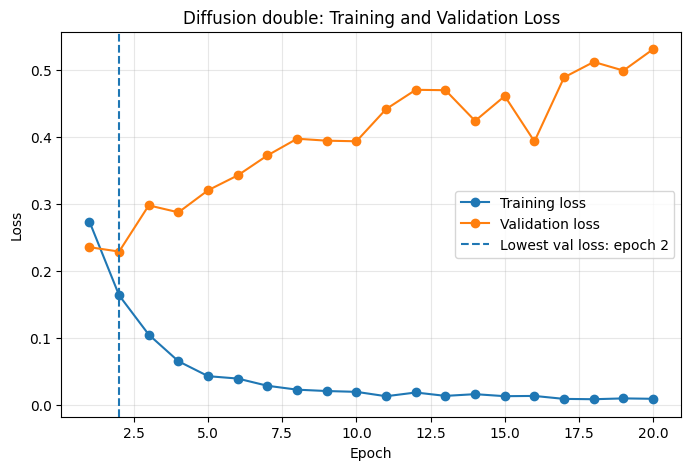

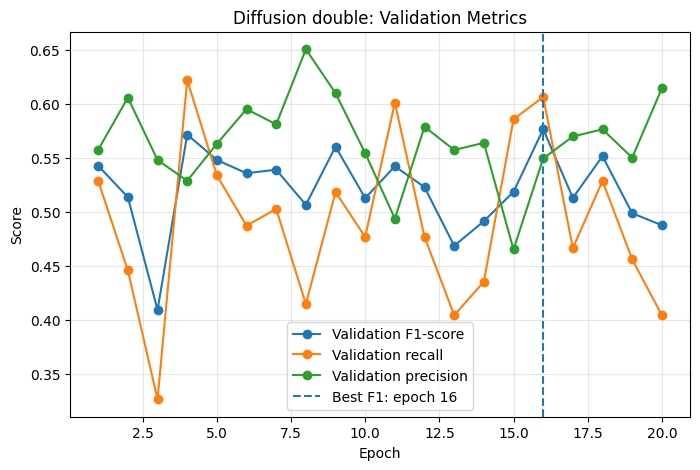


Diffusion balanced


,epoch,train_loss,val_loss,accuracy,precision,recall,f1,roc_auc
0,1,0.173954,0.238584,0.894948,0.540323,0.347150,0.422713,0.885077
1,2,0.109816,0.215191,0.908726,0.654545,0.373057,0.475248,0.909783
2,3,0.073366,0.248180,0.904133,0.604839,0.388601,0.473186,0.898323
3,4,0.048349,0.304331,0.896096,0.525641,0.637306,0.576112,0.906067
4,5,0.032473,0.327398,0.900689,0.570423,0.419689,0.483582,0.881391
5,6,0.023927,0.369934,0.904133,0.592857,0.430052,0.498498,0.885515
6,7,0.019731,0.373374,0.896670,0.529954,0.595855,0.560976,0.900598
7,8,0.017649,0.403937,0.894948,0.521368,0.632124,0.571429,0.897223
8,9,0.013743,0.390866,0.904707,0.578035,0.518135,0.546448,0.901083
9,10,0.012292,0.462003,0.907003,0.620155,0.414508,0.496894,0.879026


Lowest validation loss:
Epoch 2, val_loss = 0.2152

Highest validation F1-score:
Epoch 11, F1 = 0.5902


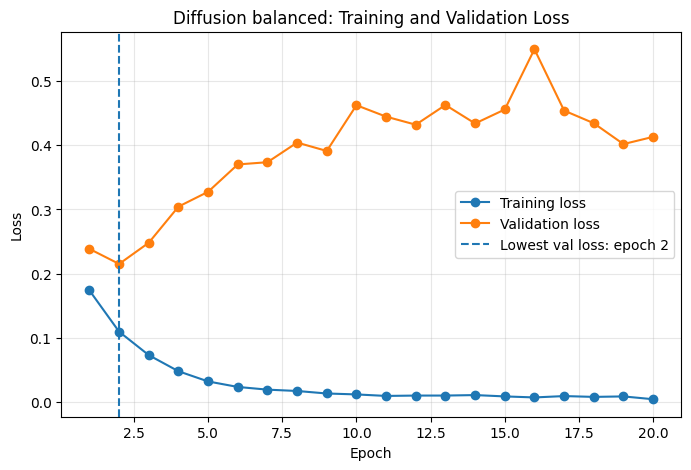

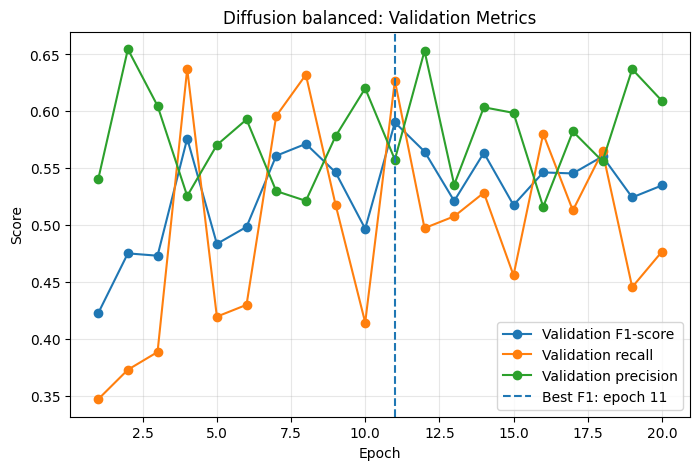

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

HISTORY_FILES = {
    "Diffusion double": Path(
        "/content/drive/MyDrive/bachelor_thesis_data/results/tables/"
        "diffusion_augmentation_double_training_history.csv"
    ),
    "Diffusion balanced": Path(
        "/content/drive/MyDrive/bachelor_thesis_data/results/tables/"
        "diffusion_augmentation_balanced_training_history.csv"
    ),
}

FIGURE_DIR = Path(
    "/content/drive/MyDrive/bachelor_thesis_data/results/figures"
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

for experiment_name, history_path in HISTORY_FILES.items():

    history_df = pd.read_csv(history_path)

    print(f"\n{experiment_name}")
    display(history_df)

    best_val_loss_idx = history_df["val_loss"].idxmin()
    best_val_loss_epoch = int(
        history_df.loc[best_val_loss_idx, "epoch"]
    )
    best_val_loss = float(
        history_df.loc[best_val_loss_idx, "val_loss"]
    )

    best_f1_idx = history_df["f1"].idxmax()
    best_f1_epoch = int(
        history_df.loc[best_f1_idx, "epoch"]
    )
    best_f1 = float(
        history_df.loc[best_f1_idx, "f1"]
    )

    print("Lowest validation loss:")
    print(
        f"Epoch {best_val_loss_epoch}, "
        f"val_loss = {best_val_loss:.4f}"
    )

    print("\nHighest validation F1-score:")
    print(
        f"Epoch {best_f1_epoch}, "
        f"F1 = {best_f1:.4f}"
    )

    filename_prefix = experiment_name.lower().replace(" ", "_")

    plt.figure(figsize=(8, 5))

    plt.plot(
        history_df["epoch"],
        history_df["train_loss"],
        marker="o",
        label="Training loss"
    )

    plt.plot(
        history_df["epoch"],
        history_df["val_loss"],
        marker="o",
        label="Validation loss"
    )

    plt.axvline(
        best_val_loss_epoch,
        linestyle="--",
        label=f"Lowest val loss: epoch {best_val_loss_epoch}"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{experiment_name}: Training and Validation Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.savefig(
        FIGURE_DIR / f"{filename_prefix}_loss_curve.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.figure(figsize=(8, 5))

    plt.plot(
        history_df["epoch"],
        history_df["f1"],
        marker="o",
        label="Validation F1-score"
    )

    plt.plot(
        history_df["epoch"],
        history_df["recall"],
        marker="o",
        label="Validation recall"
    )

    plt.plot(
        history_df["epoch"],
        history_df["precision"],
        marker="o",
        label="Validation precision"
    )

    plt.axvline(
        best_f1_epoch,
        linestyle="--",
        label=f"Best F1: epoch {best_f1_epoch}"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title(f"{experiment_name}: Validation Metrics")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.savefig(
        FIGURE_DIR / f"{filename_prefix}_validation_metrics.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

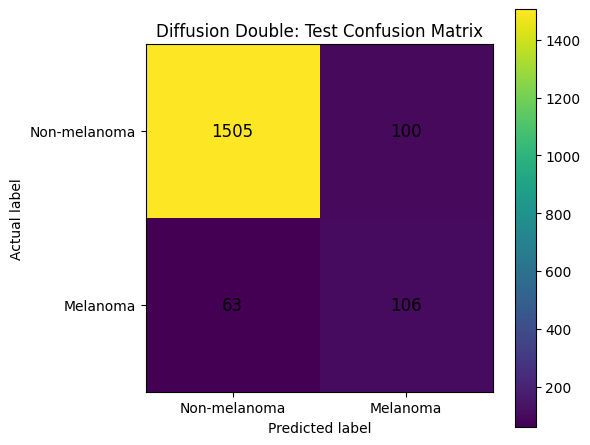

Saved:
/content/drive/MyDrive/bachelor_thesis_data/results/figures/diffusion_augmentation_double_test_confusion_matrix.png


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

cm = np.array([
    [1505, 100],
    [  63, 106]
])

class_names = ["Non-melanoma", "Melanoma"]

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm)

ax.set_title("Diffusion Double: Test Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("Actual label")

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            int(cm[i, j]),
            ha="center",
            va="center",
            fontsize=12
        )

plt.colorbar(im, ax=ax)
plt.tight_layout()

FIGURE_DIR = Path(
    "/content/drive/MyDrive/bachelor_thesis_data/results/figures"
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = (
    FIGURE_DIR /
    "diffusion_augmentation_double_test_confusion_matrix.png"
)

plt.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(OUTPUT_PATH)

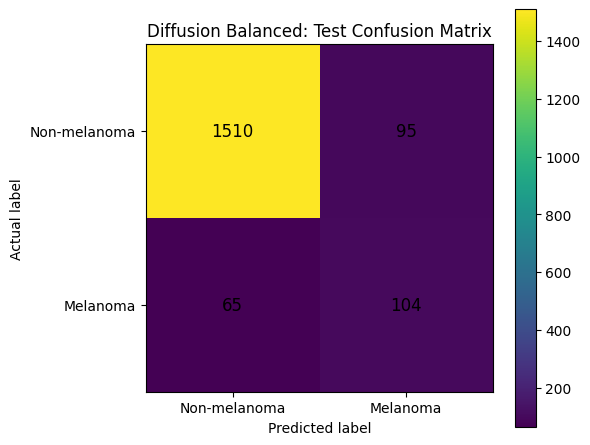

Saved:
/content/drive/MyDrive/bachelor_thesis_data/results/figures/diffusion_augmentation_balanced_test_confusion_matrix.png


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

cm = np.array([
    [1510,  95],
    [  65, 104]
])

class_names = ["Non-melanoma", "Melanoma"]

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm)

ax.set_title("Diffusion Balanced: Test Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("Actual label")

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            int(cm[i, j]),
            ha="center",
            va="center",
            fontsize=12
        )

plt.colorbar(im, ax=ax)
plt.tight_layout()

FIGURE_DIR = Path(
    "/content/drive/MyDrive/bachelor_thesis_data/results/figures"
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = (
    FIGURE_DIR /
    "diffusion_augmentation_balanced_test_confusion_matrix.png"
)

plt.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(OUTPUT_PATH)